In [10]:
# DB에서 데이터 불러오기
import pymysql
import pandas as pd

conn = pymysql.connect(
    host="localhost",
    user="root",
    password="12345",
    database="homefit",
    charset="utf8"
)

query = "SELECT * FROM user_points ORDER BY created_at"

df = pd.read_sql(query, conn)

df.head()

C:\Users\smhrd1\AppData\Local\Temp\ipykernel_9052\2265150129.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,user_id,posture_score,duration,continuity,goal_score,total_point,created_at
0,1,test_user,90.0,60,15,80.0,75.0,2026-03-06 12:02:20
1,2,test_user,90.0,60,15,80.0,75.0,2026-03-06 12:36:44
2,3,user1,90.0,30,5,100.0,78.0,2026-03-06 12:40:37
3,4,test_user,90.0,60,15,80.0,75.0,2026-03-12 09:33:03
4,5,user1,90.0,30,5,70.0,68.0,2026-03-12 10:04:24


In [11]:
# 날짜 + 점수만 정리
df["created_at"] = pd.to_datetime(df["created_at"])

data = df[["created_at", "total_point"]]

data.head()

,created_at,total_point
0,2026-03-06 12:02:20,75.0
1,2026-03-06 12:36:44,75.0
2,2026-03-06 12:40:37,78.0
3,2026-03-12 09:33:03,75.0
4,2026-03-12 10:04:24,68.0


In [7]:
# 일별 평균 포인트 만들기
daily = data.groupby(
    data["created_at"].dt.date
).mean()

daily

,created_at,total_point
created_at,,
2026-03-06,2026-03-06 12:26:33.666666496,76.0
2026-03-12,2026-03-12 09:33:03.000000000,75.0


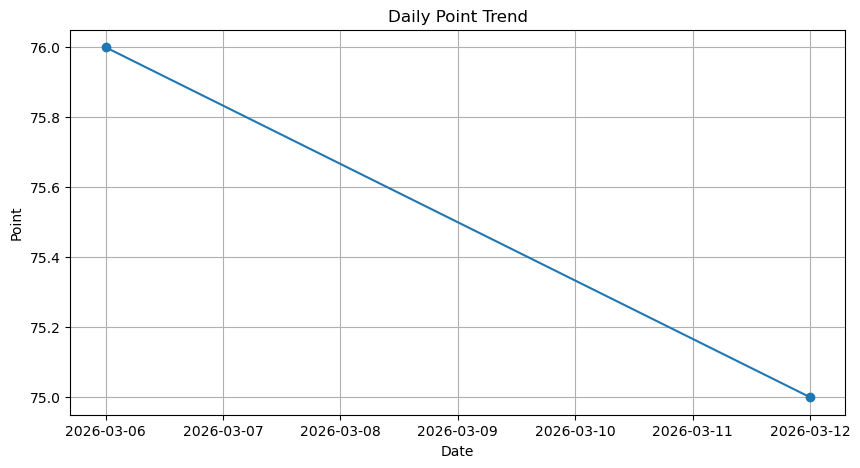

In [8]:
# 그래프 그리기
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(daily.index, daily["total_point"], marker="o")

plt.title("Daily Point Trend")
plt.xlabel("Date")
plt.ylabel("Point")

plt.grid()

plt.show()